# 03 — Reaction Time Model

### Exponential Indifference Model

This notebook models participants' reaction times (RT) as a function of the
subjective value difference between the immediate and delayed options.

The Exponential Indifference Model is defined as:

\[
RT = a + b \cdot e^{-c|\Delta SV|}
\]

where:

- \(RT\) = predicted reaction time in milliseconds
- \(\Delta SV\) = subjective value difference
- \(a\) = asymptotic reaction time
- \(b\) = maximum RT contribution
- \(c\) = rate at which RT decreases with increasing value difference

The model is fitted on the training data and evaluated on the held-out test data.

### 1. Objective

The objective is to test whether reaction times can be explained by the
difference in subjective value between the available options.

The model is fitted using nonlinear optimization on the training set and
evaluated on the test set using MAE, RMSE, and \(R^2\).

A mean-reaction-time baseline is also used for comparison.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/aarohi_verma/Downloads/final_project/ICCS2026_Final_Project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from src.config import DATA_DIR
from src.data_loader import load_all_participants
from src.preprocessing import get_split, combine_participants
from src.discounting import add_subjective_values

from src.rt_models import (
    predict_rt_exponential,
    fit_rt_model_exponential,
    add_predicted_rt_exponential
)

### 2. Load and Prepare Data

The preprocessed participant data are loaded and separated into training
and test sets. The training set is used for parameter estimation, while
the test set is reserved for final evaluation.

In [3]:
participants = load_all_participants(DATA_DIR)

In [4]:
train = get_split(participants, "train")
test = get_split(participants, "test")

combined_train = combine_participants(train)
combined_test = combine_participants(test)

print("Train:", combined_train.shape)
print("Test:", combined_test.shape)

Train: (8920, 8)
Test: (20070, 8)


In [5]:
combined_train = add_subjective_values(
    combined_train,
    k=0.01
)

combined_test = add_subjective_values(
    combined_test,
    k=0.01
)

print("Training columns:")
print(combined_train.columns.tolist())

print("\nTest columns:")
print(combined_test.columns.tolist())

Training columns:
['immOutcome', 'delOutcome', 'delay', 'choice', 'p_imm', 'condition', 'RT', 'participant', 'SV_immediate', 'SV_delayed', 'value_difference']

Test columns:
['immOutcome', 'delOutcome', 'delay', 'choice', 'p_imm', 'condition', 'RT', 'participant', 'SV_immediate', 'SV_delayed', 'value_difference']


### 3. Data Quality Check

Before fitting the model, we check for missing values in reaction time
and subjective value difference.

In [6]:
print("Missing values in training data:")
print(
    combined_train[["RT", "value_difference"]]
    .isnull()
    .sum()
)

print("\nMissing values in test data:")
print(
    combined_test[["RT", "value_difference"]]
    .isnull()
    .sum()
)

Missing values in training data:
RT                  34
value_difference     0
dtype: int64

Missing values in test data:
RT                  59
value_difference    60
dtype: int64


### 4. Reaction Time Exploration

Reaction time distributions are examined before model fitting to understand
the range and variability of observed responses.

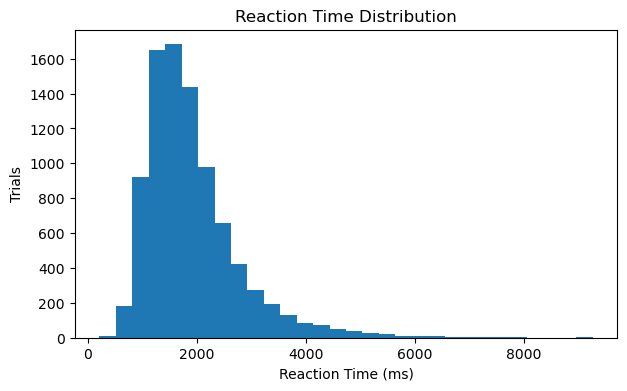

In [7]:
plt.figure(figsize=(7, 4))

plt.hist(
    combined_train["RT"].dropna(),
    bins=30
)

plt.xlabel("Reaction Time (ms)")
plt.ylabel("Trials")
plt.title("Reaction Time Distribution")

plt.show()

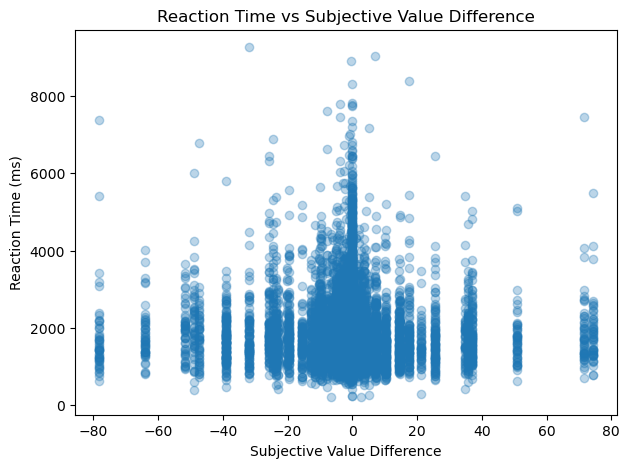

In [8]:
plt.figure(figsize=(7, 5))

plt.scatter(
    combined_train["value_difference"],
    combined_train["RT"],
    alpha=0.3
)

plt.xlabel("Subjective Value Difference")
plt.ylabel("Reaction Time (ms)")
plt.title("Reaction Time vs Subjective Value Difference")

plt.show()

### 5. Exponential Indifference Model

The Exponential Indifference Model assumes that reaction time decreases
exponentially as the absolute subjective value difference increases:

\[
RT = a + b \cdot e^{-c|\Delta SV|}
\]

The parameters \(a\), \(b\), and \(c\) are estimated from the training data
using nonlinear optimization.

In [9]:
result = fit_rt_model_exponential(combined_train)

print("Optimization successful:", result.success)
print("Message:", result.message)
print("Final MSE:", result.fun)

Optimization successful: True
Message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Final MSE: 778396.7139754893


In [10]:
exp_a, exp_b, exp_c = result.x

print(f"a = {exp_a:.4f}")
print(f"b = {exp_b:.4f}")
print(f"c = {exp_c:.6f}")

a = 1827.3407
b = 351.3648
c = 10.200072


### 6. Model Fit

The fitted exponential function is visualized together with the observed
training reaction times.

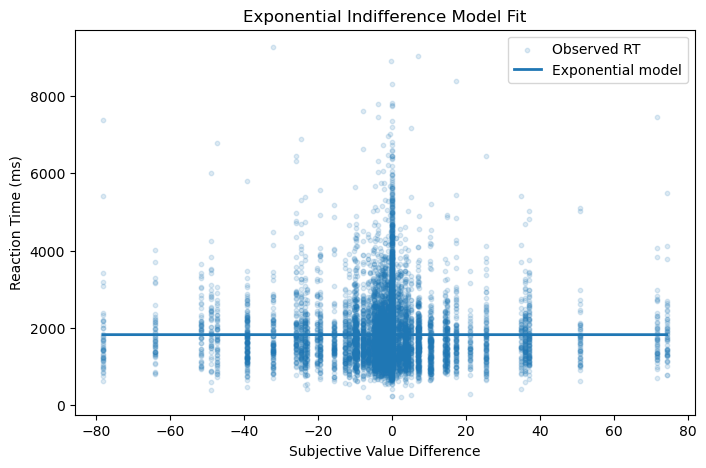

In [11]:
x = np.linspace(
    combined_train["value_difference"].min(),
    combined_train["value_difference"].max(),
    300
)

y = predict_rt_exponential(
    x,
    exp_a,
    exp_b,
    exp_c
)

plt.figure(figsize=(8, 5))

plt.scatter(
    combined_train["value_difference"],
    combined_train["RT"],
    alpha=0.15,
    s=10,
    label="Observed RT"
)

plt.plot(
    x,
    y,
    linewidth=2,
    label="Exponential model"
)

plt.xlabel("Subjective Value Difference")
plt.ylabel("Reaction Time (ms)")
plt.title("Exponential Indifference Model Fit")
plt.legend()

plt.show()

### 7. Test Set Prediction

The fitted parameters are applied to the held-out test set.
No model fitting is performed on the test data.

In [12]:
test_pred = add_predicted_rt_exponential(
    combined_test,
    exp_a,
    exp_b,
    exp_c
)

print(
    test_pred[
        ["RT", "value_difference", "predicted_RT"]
    ].head()
)

       RT  value_difference  predicted_RT
0  1507.5         -0.608925   1828.045885
1  1260.5          3.045789   1827.340669
2  2113.5          7.976316   1827.340669
3  1764.1          1.957143   1827.340670
4  1984.3         -0.795385   1827.445947


### 8. Model Evaluation

Evaluation is performed only on test observations for which both the
observed reaction time and model prediction are available.

In [13]:
evaluation = test_pred.dropna(
    subset=["RT", "predicted_RT"]
).copy()

print(
    "Test observations before removing missing RT:",
    len(test_pred)
)

print(
    "Test observations used for evaluation:",
    len(evaluation)
)

y_true = evaluation["RT"]
y_pred = evaluation["predicted_RT"]

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

r2 = r2_score(y_true, y_pred)

print(f"\nMAE:  {mae:.2f} ms")
print(f"RMSE: {rmse:.2f} ms")
print(f"R²:   {r2:.4f}")

Test observations before removing missing RT: 20070
Test observations used for evaluation: 19952

MAE:  688.73 ms
RMSE: 933.11 ms
R²:   -0.0239


### 9. Baseline Comparison

To determine whether the Exponential Indifference Model provides useful
predictive information, it is compared against a simple baseline that
predicts the mean training reaction time for every test observation.

In [14]:
baseline_prediction = combined_train["RT"].mean()

baseline_predictions = np.full(
    len(evaluation),
    baseline_prediction
)

baseline_mae = mean_absolute_error(
    evaluation["RT"],
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        evaluation["RT"],
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    evaluation["RT"],
    baseline_predictions
)

print(f"Mean RT baseline: {baseline_prediction:.2f} ms")
print(f"Baseline MAE:     {baseline_mae:.2f} ms")
print(f"Baseline RMSE:    {baseline_rmse:.2f} ms")
print(f"Baseline R²:      {baseline_r2:.4f}")

Mean RT baseline: 1913.05 ms
Baseline MAE:     714.47 ms
Baseline RMSE:    944.67 ms
Baseline R²:      -0.0495


### 10. Model Comparison

In [15]:
results = pd.DataFrame({
    "Model": [
        "Mean RT Baseline",
        "Exponential Indifference Model"
    ],
    "MAE (ms)": [
        baseline_mae,
        mae
    ],
    "RMSE (ms)": [
        baseline_rmse,
        rmse
    ],
    "R²": [
        baseline_r2,
        r2
    ]
})

results

,Model,MAE (ms),RMSE (ms),R²
0,Mean RT Baseline,714.465627,944.669615,-0.049470
1,Exponential Indifference Model,688.729064,933.111761,-0.023947


In [16]:
mae_improvement = (
    (baseline_mae - mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - rmse) / baseline_rmse
) * 100

print(f"MAE improvement:  {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

MAE improvement:  3.60%
RMSE improvement: 1.22%


### 11. Actual vs Predicted Reaction Time

The relationship between observed and predicted reaction times is shown
for all test observations used in evaluation.

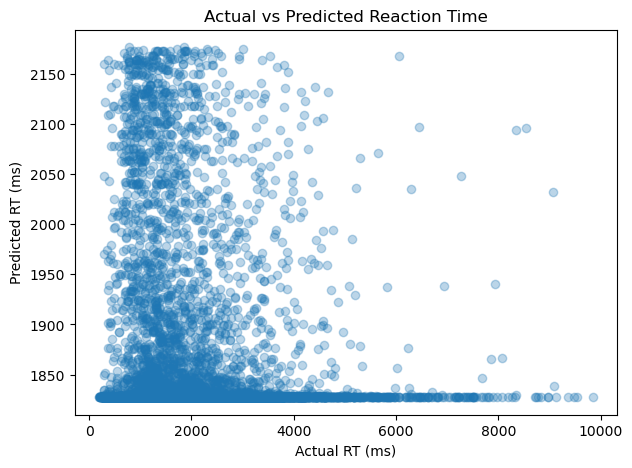

In [17]:
plt.figure(figsize=(7, 5))

plt.scatter(
    evaluation["RT"],
    evaluation["predicted_RT"],
    alpha=0.3
)

plt.xlabel("Actual RT (ms)")
plt.ylabel("Predicted RT (ms)")
plt.title("Actual vs Predicted Reaction Time")

plt.show()

### 12. Predicted RT vs Subjective Value Difference

This plot shows the reaction-time predictions generated by the fitted
Exponential Indifference Model across the observed range of subjective
value differences.

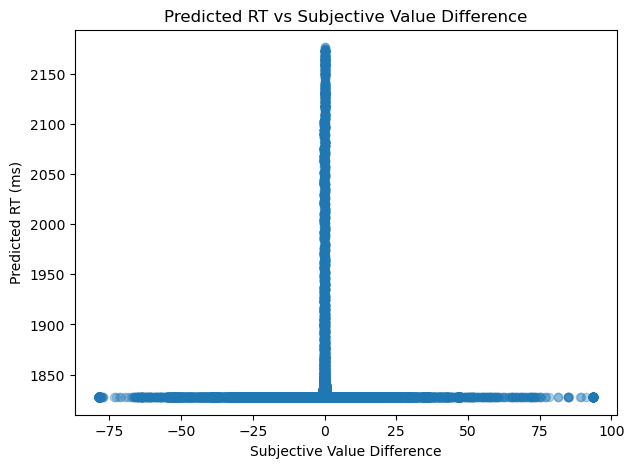

In [18]:
plt.figure(figsize=(7, 5))

plt.scatter(
    evaluation["value_difference"],
    evaluation["predicted_RT"],
    alpha=0.3
)

plt.xlabel("Subjective Value Difference")
plt.ylabel("Predicted RT (ms)")
plt.title("Predicted RT vs Subjective Value Difference")

plt.show()

### 13. Summary

The Exponential Indifference Model was fitted to reaction-time data using
subjective value difference as the explanatory variable.

The model achieved:

- MAE: approximately 688.73 ms
- RMSE: approximately 933.11 ms
- R²: approximately -0.0239

The mean reaction-time baseline achieved:

- MAE: approximately 714.47 ms
- RMSE: approximately 944.67 ms
- R²: approximately -0.0495

The Exponential Indifference Model therefore performs better than the
mean-RT baseline on MAE and RMSE, although the improvement is modest and
the negative R² indicates that substantial trial-level variability in
reaction time remains unexplained.

This suggests that subjective value difference captures some information
about reaction time, but additional factors are likely required to explain
individual trial-level RT variability.